0.08


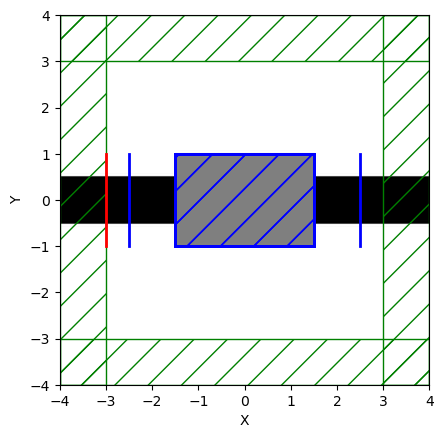

In [2]:
## mode converter ##
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 30

# cell size
Sx = 8
Sy = 8
cell_size = mp.Vector3(Sx, Sy, 0)
pml_layers = [mp.PML(1.0)]
 

# source
fcen = 1 / 0.75 # 750nm
width = 0.2
fwidth = width * fcen
source_center = [-3, 0, 0]
source_size = mp.Vector3(0, 2, 0)
src = mp.GaussianSource(frequency = fcen, fwidth=fwidth)
source = [
    mp.EigenModeSource(
        src,
        eig_band=1,
        eig_match_freq=True,
        direction=mp.X,
        size=source_size,
        center=source_center,
        eig_parity=mp.ODD_Z
    )
]


# design region
Dx = 3
Dy = 2
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution + 1)
Ny = int(Dy * design_region_resolution + 1)

design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))


# geometry 
geometry = [
    mp.Block(
            center=mp.Vector3(-2.75, 0),
            material=Si,
            size=mp.Vector3(2.5, 1, 0)
            ),
    mp.Block(
            center=mp.Vector3(2.75, 0),
            material=Si,
            size=mp.Vector3(2.5, 1, 0)
            ),
    mp.Block(
            center=design_region.center,
            material=design_variables,
            size=design_region.size
            )
]


# filter
filter_radius = 0.08
eta_i = (0.5)
eta_e = 0.55
eta_d = 1 - eta_e
print(filter_radius)

def mapping(x, beta, eta):
    x_reshaped = npa.reshape(x, (Nx, Ny))

    # cone shaped filter
    x_filtered = mpa.conic_filter(
        x_reshaped, 
        filter_radius, 
        design_region.size.x,
        design_region.size.y,
        design_region_resolution
    )

    # projection
    x_proj = mpa.tanh_projection(x_filtered, beta, eta)

    return x_proj.flatten()


# simulation
sim =mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    resolution=resolution,
)


# objective function
TE00 = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(center=mp.Vector3(-2.5,0,0), size=mp.Vector3(y=2)),
    mode=1,
    eig_parity=mp.ODD_Z
)

TE20 = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(center=mp.Vector3(2.5,0,0), size=mp.Vector3(y=2)),
    mode=3,
    eig_parity=mp.ODD_Z
)

ob_list = [TE00, TE20]

def J(source, monitor):
    return npa.abs(monitor) ** 2 / npa.abs(source) ** 2


opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=[J],
    objective_arguments=ob_list,
    design_regions=[design_region],
    fcen=fcen,
    df=0,
    nf=1,
)

x0 = 0.5 * np.ones((Nx * Ny, ))
opt.update_design([x0])

opt.plot2D(True)
plt.show()




In [30]:
evaluation_history = []
sensitivity = [0]
cur_iter = [0]

beta = 1

def f(x, gradient,beta):
    print("Current iteration: {}".format(cur_iter[0] + 1))

    f0, dJ_du = opt([mapping(x, beta, eta_i)])
    
    if gradient.size > 0:
        d = np.array(dJ_du)

        if d.ndim == 2:
           g = np.sum(d, axis=0)
        else:
            g = d

        g = np.real(np.ravel(g))

        gradient[:] = vjp(mapping, 0)(x, beta, eta_i, g)
    
    evaluation_history.append(np.real(f0[0]))
    sensitivity[0] = dJ_du
    
    cur_iter[0] += 1
    return np.real(f0[0])


algorithm = nlopt.LD_MMA
n = Nx * Ny
maxeval = 10

beta = 1       # 시작 β
beta_scale = 2        # β를 2배씩 키움
num_betas = 6      # β 단계 수 (총 6번)
update_factor = 20    # 각 β 단계에서 NLopt 반복 횟수(= maxeval)
for iters in range(num_betas):
    solver = nlopt.opt(algorithm, n)   # 매 β 단계마다 solver 새로 생성
    solver.set_lower_bounds(0)
    solver.set_upper_bounds(1)

    solver.set_max_objective(lambda a, g: f(a, g, beta))
    solver.set_maxeval(update_factor)

    x0[:] = solver.optimize(x0)
    beta = beta * beta_scale

Current iteration: 1
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 2
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 3
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 4
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 5
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 6
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 7
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 8
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 9
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 10
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 11
Starting forward run...
Starting adjoint run...

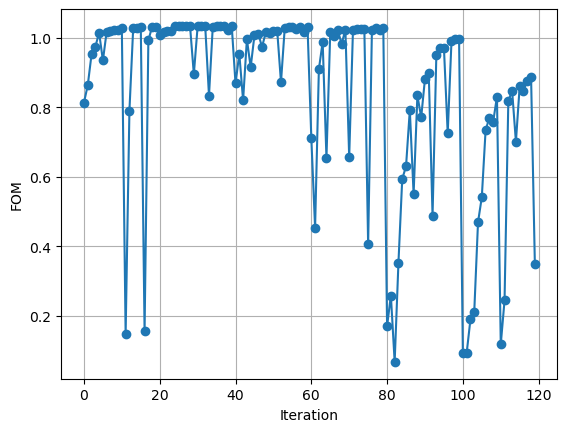

In [31]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()

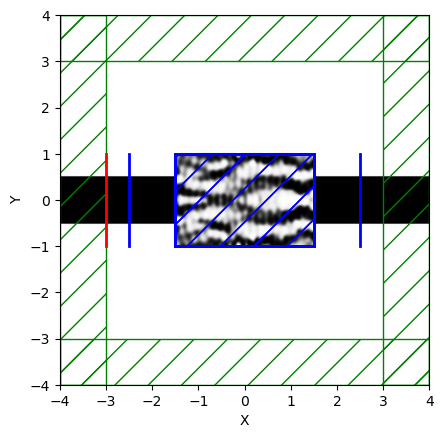

In [32]:
opt.plot2D(True)
plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import meep as mp

def plot_field_over_eps(sim, field=mp.Ez, component="real",
                        overlay_alpha=0.75, eps_cmap="Greys", field_cmap="RdBu",
                        title=None, savepath=None):
    """
    sim: mp.Simulation
    field: mp.Ez / mp.Ey / mp.Hz ...
    component: "real" | "imag" | "abs"
    overlay_alpha: 필드 오버레이 투명도
    """

    # 1) epsilon grid (2D)
    eps = sim.get_array(center=mp.Vector3(), size=sim.cell_size, component=mp.Dielectric)

    # 2) field grid (2D)
    f = sim.get_array(center=mp.Vector3(), size=sim.cell_size, component=field)

    if component == "real":
        fplot = np.real(f)
    elif component == "imag":
        fplot = np.imag(f)
    elif component == "abs":
        fplot = np.abs(f)
    else:
        raise ValueError("component must be one of: real, imag, abs")

    # 3) 좌표 extent (imshow용)
    # get_array는 shape=(Nx,Ny) or (Ny,Nx) 케이스가 있어 transpose로 맞추는 경우가 많음
    # 아래는 "보기 좋게" y가 위로 가도록 origin='lower'를 사용
    extent = [-sim.cell_size.x/2, sim.cell_size.x/2, -sim.cell_size.y/2, sim.cell_size.y/2]

    # 4) plot
    plt.figure(figsize=(10, 4))

    # epsilon 배경 (회색)
    plt.imshow(eps.T, cmap=eps_cmap, origin="lower", extent=extent, interpolation="nearest")

    # 필드 오버레이 (red/blue), 중심 0 기준으로 스케일링
    vmax = np.max(np.abs(fplot)) + 1e-12
    plt.imshow(fplot.T, cmap=field_cmap, origin="lower", extent=extent,
               alpha=overlay_alpha, vmin=-vmax, vmax=vmax, interpolation="bilinear")

    plt.xlabel("x")
    plt.ylabel("y")
    if title:
        plt.title(title)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    plt.show()


# -------------------------------
# 사용 예시
# -------------------------------
# 1) 시뮬레이션을 충분히 run한 뒤에 (steady state 이후)
# sim.run(until=...)
#
# 2) 플롯 호출
# plot_field_over_eps(sim, field=mp.Ez, component="real",
#                     title="Re(Ez) over epsilon", savepath="field_overlay.png")